In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [33]:
df=pd.read_csv(r"C:\Users\HP\Downloads\warehouse_demand_prediction.csv")
df

,Date,Product_ID,Warehouse_ID,Product_Category,Inventory_Level,Units_Sold,Price,Discount,Promotion,Holiday,Temperature,Demand
0,2023-01-01,P001,W001,Electronics,540,171,54.31,10,1,0,22.8,171
1,2023-01-01,P001,W002,Electronics,523,131,52.36,15,1,0,26.5,141
2,2023-01-01,P001,W003,Electronics,617,124,53.92,0,0,0,21.6,133
3,2023-01-01,P001,W004,Electronics,550,121,54.26,0,0,0,23.5,123
4,2023-01-01,P002,W001,Electronics,505,158,70.65,0,0,0,22.7,170
...,...,...,...,...,...,...,...,...,...,...,...,...
35067,2025-12-31,P007,W004,Home,588,161,48.21,0,0,0,22.2,161
35068,2025-12-31,P008,W001,Home,525,111,64.36,0,0,0,24.9,132
35069,2025-12-31,P008,W002,Home,457,80,67.53,0,0,0,22.1,81
35070,2025-12-31,P008,W003,Home,733,163,67.91,0,1,0,23.3,177


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35072 entries, 0 to 35071
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              35072 non-null  object 
 1   Product_ID        35072 non-null  object 
 2   Warehouse_ID      35072 non-null  object 
 3   Product_Category  35072 non-null  object 
 4   Inventory_Level   35072 non-null  int64  
 5   Units_Sold        35072 non-null  int64  
 6   Price             35072 non-null  float64
 7   Discount          35072 non-null  int64  
 8   Promotion         35072 non-null  int64  
 9   Holiday           35072 non-null  int64  
 10  Temperature       35072 non-null  float64
 11  Demand            35072 non-null  int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 3.2+ MB


In [37]:
df.isnull().sum()

Date                0
Product_ID          0
Warehouse_ID        0
Product_Category    0
Inventory_Level     0
Units_Sold          0
Price               0
Discount            0
Promotion           0
Holiday             0
Temperature         0
Demand              0
dtype: int64

In [39]:
df.shape

(35072, 12)

In [41]:
df.columns

Index(['Date', 'Product_ID', 'Warehouse_ID', 'Product_Category',
       'Inventory_Level', 'Units_Sold', 'Price', 'Discount', 'Promotion',
       'Holiday', 'Temperature', 'Demand'],
      dtype='object')

In [43]:
df['Date']=pd.to_datetime(df['Date'])

df['Year']=df['Date'].dt.year
df['Month']=df['Date'].dt.month
df['DayOfWeek']=df['Date'].dt.dayofweek


In [49]:
le = LabelEncoder()

df['Product_ID'] = le.fit_transform(df['Product_ID'])
df['Warehouse_ID'] = le.fit_transform(df['Warehouse_ID'])
df['Product_Category'] = le.fit_transform(df['Product_Category'])

In [51]:
X = df.drop(columns=['Date', 'Demand'])
y = df['Demand']

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [57]:
model = RandomForestRegressor(n_estimators=28,random_state=42,n_jobs=1)
model.fit(X_train, y_train)


RandomForestRegressor(n_estimators=28, n_jobs=1, random_state=42)

In [59]:
y_pred = model.predict(X_test)

In [79]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 SCORE:" ,r2_score(y_test, y_pred))

MAE: 4.592658588738417
RMSE: 5.827087393253827
R2 SCORE: 0.9740358650964609


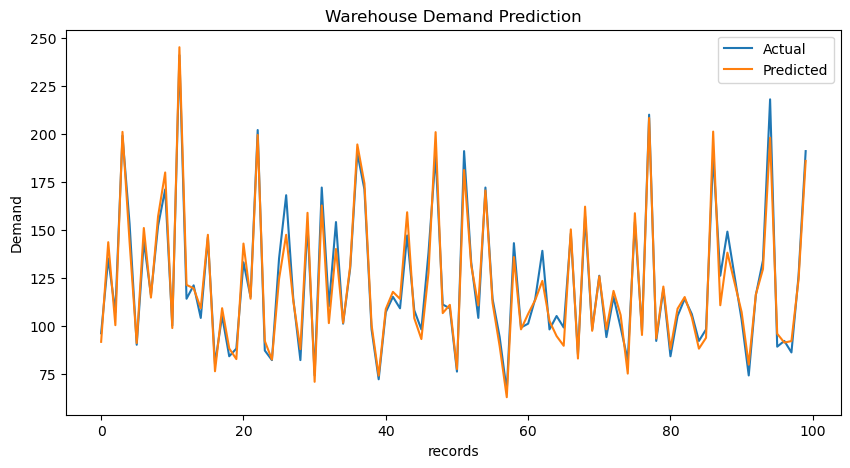

In [81]:
# Actual vs Predicted
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:100], label='Actual')
plt.plot(y_pred[:100], label='Predicted')

plt.xlabel('records')
plt.ylabel('Demand')
plt.title('Warehouse Demand Prediction')
plt.legend()
plt.show()